Loaded data from 1 files.
Max c_msdpb[4] up to 100000 in log.lammps: 304.80177


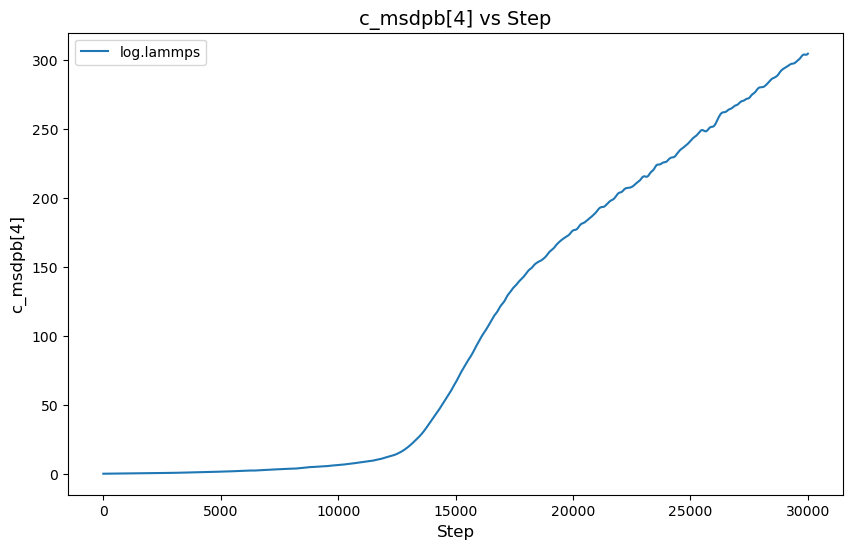

In [3]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt

def read_lammps_log(filename):
    """Reads thermodynamic data from a LAMMPS log file."""
    with open(filename, 'r') as file:
        lines = file.readlines()

    thermo_data = []
    columns = []
    start_reading = False
    thermo_re = re.compile(r"\s*-?\d+")  # Updated to include negative numbers

    for line in lines:
        if 'Step' in line and not start_reading:
            columns = line.split()
            start_reading = True
            continue

        if start_reading:
            if thermo_re.match(line):
                thermo_data.append([float(x) for x in line.split()])
            elif line.strip() == "":
                break

    if thermo_data:
        return pd.DataFrame(thermo_data, columns=columns)
    return None

def plot_multiple_columns(log_dfs, log_files, column_name, x_axis_column, max_step=None):
    plt.figure(figsize=(10, 6))

    for log_df, log_file in zip(log_dfs, log_files):
        if column_name in log_df.columns and x_axis_column in log_df.columns:
            df = log_df
            if max_step is not None:
                df = df[df[x_axis_column] <= max_step]
            plt.plot(df[x_axis_column], df[column_name], label=os.path.basename(log_file))
        else:
            print(f"Required columns '{column_name}' or '{x_axis_column}' not found in {log_file}.")

    plt.xlabel(x_axis_column, fontsize=12)
    plt.ylabel(column_name, fontsize=12)
    plt.title(f'{column_name} vs {x_axis_column}', fontsize=14)
    plt.legend()
    plt.grid(False)
    plt.show()

def main(log_files, column_name, x_axis_column, max_step=None):
    log_dfs = [read_lammps_log(f) for f in log_files]

    if any(df is None for df in log_dfs):
        print("Failed to load data from one or more log files.")
        return

    print(f"Loaded data from {len(log_files)} files.")

    for log_df, log_file in zip(log_dfs, log_files):
        if column_name in log_df.columns:
            df = log_df
            if max_step is not None:
                df = df[df[x_axis_column] <= max_step]
            max_val = df[column_name].max()
            print(f"Max {column_name} up to {max_step if max_step else 'end'} in {os.path.basename(log_file)}: {max_val}")
        else:
            print(f"Column '{column_name}' not found in {log_file}.")

    plot_multiple_columns(log_dfs, log_files, column_name, x_axis_column, max_step)

if __name__ == "__main__":
    log_files = [                   # "/home/pranjul/lammps/pran/shear/xy/nptinallxyz/log.lammps",
                 #"/home/pranjul/lammps/pran/shear/yz/log.lammps",
                          #        "/home/pranjul/lammps/pran/shear/xz/log.lammps",
       # "/home/pranjul/lammps/pran/new_with_anisotropy/100K/10/check_densification/log.lammps",
       # "/home/pranjul/lammps/pran/new_with_anisotropy/150K/10/check_densification/log.lammps",
       # "/home/pranjul/lammps/pran/new_with_anisotropy/200K/10/check_densification/log.lammps",
       # "/home/pranjul/lammps/pran/new_with_anisotropy/250K/10/check_densification/log.lammps",
        #"/home/pranjul/lammps/pran/new_with_anisotropy/100K/10/log.lammps",
        #"/home/pranjul/lammps/pran/new_with_anisotropy/150K/10/log.lammps",
                # "/home/pranjul/lammps/pran/new_with_anisotropy/200K/10/log.lammps",
                       #  "/home/pranjul/lammps/pran/new_with_anisotropy/250K/10/log.lammps"
      #"/home/pranjul/lammps/pran/new_with_anisotropy/300K/X/777/log.lammps",
       # "/home/pranjul/lammps/pran/new_with_anisotropy/300K/Y/777/log.lammps",
        #"/home/pranjul/lammps/pran/new_with_anisotropy/300K/Z/777/log.lammps",     
        #"/home/pranjul/lammps/pran/new_with_anisotropy/300K/Biaxial/777/log.lammps",      
       # "/home/pranjul/lammps/pran/new_with_anisotropy/300K/Triaxial/777/log.lammps",       
        "/home/pranjul/lammps/pran/new_with_anisotropy/300K/Xcomp/log.lammps",      
        #"/home/pranjul/lammps/pran/new_with_anisotropy/300K/Ycomp/log.lammps",       
        #"/home/pranjul/lammps/pran/new_with_anisotropy/300K/Zcomp/log.lammps",       
        #"/home/pranjul/lammps/pran/new_with_anisotropy/300K/Biaxial_comp/log.lammps",       
        #"/home/pranjul/lammps/pran/new_with_anisotropy/300K/Triaxial_comp/log.lammps",
   # "/home/pranjul/lammps/pran/new_with_anisotropy/300K/X/sr/8/log.lammps",       
      #  "/home/pranjul/lammps/pran/new_with_anisotropy/300K/X/sr/9/log.lammps",
      #  "/home/pranjul/lammps/pran/new_with_anisotropy/300K/X/777/log.lammps",
      #  "/home/pranjul/lammps/pran/new_with_anisotropy/300K/X/sr/11/log.lammps",
      #  "/home/pranjul/lammps/pran/new_with_anisotropy/300K/X/sr/12/log.lammps"
          ]
    column_name = 'c_msdpb[4]'
    x_axis_column = 'Step'
    max_step = 100000  #Plot upto desired x- value

    main(log_files, column_name, x_axis_column, max_step)